# 🔁 01-数据结构与算法 · 主题 7：回溯（DFS + 撤销）

> 回溯 = **穷举所有可能的分支** + **不满足就回退（撤销）**。处理排列、组合、子集、棋盘类问题的标准框架。
> 本 notebook 目标：**背熟回溯模板 → 掌握三种去重/剪枝姿势 → 吃透 9 道高频题 → 通过 25 道自测**。

**前置**：主题 6（递归/DFS）。**运行环境**：Python 3.8+，无第三方依赖。

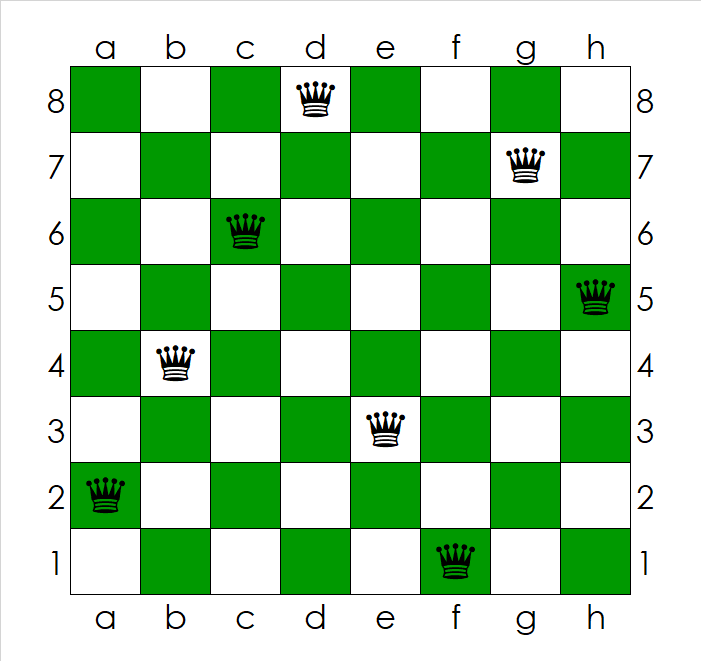

> 📷 8 皇后问题的一个解（每行/列/斜线至多一个皇后）
> *图源：Wikimedia Commons（开放授权）*


## §1 心智模型：决策树

回溯问题都可以画成一棵**决策树**：

- **节点** = 当前已选择的部分解（path）
- **边** = 每一步的可选动作（choices）
- **叶子** = 完整解（记录）或死路（剪掉）

```
            root
         /   |    \
        1    2     3        <- 第一层选择
       / \   / \
      2   3 1   3 ...       <- 第二层选择
```

回溯 vs 普通递归：回溯在递归返回后要**撤销现场**（状态回滚），让兄弟分支从相同起点出发。

### 复杂度直觉（背下来）

| 问题 | 状态数 | 每状态成本 | 总复杂度 |
|------|--------|-----------|---------|
| 子集（是否取每个元素） | $2^n$ | $O(n)$ | $O(n \cdot 2^n)$ |
| 组合 $C(n,k)$ | $\binom{n}{k}$ | $O(k)$ | $O(k \cdot \binom{n}{k})$ |
| 全排列 | $n!$ | $O(n)$ | $O(n \cdot n!)$ |
| N 皇后 | $\approx \binom{n^2}{n}$ | $O(n)$ | 指数级，剪枝后大幅缩小 |

## §2 通用模板（背熟，写题前先默写）

```python
def backtrack(path, choices):
    if 满足结束条件:
        记录解(path)
        return
    for 每个可选动作 c in choices:
        if 不合法(c):
            continue          # 剪枝：放弃这一支
        做选择(c)             # 状态前进
        backtrack(path, choices)
        撤销选择(c)           # 状态回滚（回溯的灵魂）
```

**四要素**：路径（path）、选择列表（choices）、结束条件、剪枝条件。

> ⚠️ **撤销必须对称**：做了 `path.append(x)` 就必须 `path.pop()`；修改了计数器/集合也必须回滚，否则兄弟分支被污染。

## §3 子集（LeetCode 78）

**题目**：返回所有子集（含空集与自身），共 $2^n$ 个。

**思路**：对每个元素**选或不选**两条分支；用 `start` 下标保证不回头（不产生重复子集）。

**为什么用 `start`**：子集无序——选了 1 后再也不能选 <1 的刻场景，避免 `[1,2]` 与 `[2,1]` 重复。

**复杂度**：$O(n \cdot 2^n)$ 时间，$O(n)$ 递归深度（不含结果空间）。

> 💡 对照：二进制枚举 `for mask in range(1 << n)` 等价，第 $i$ 位为 1 表示选 $nums[i]$。

In [ ]:
def subsets(nums):
    res = []
    def backtrack(start, path):
        res.append(path[:])            # 每个节点都是一个子集
        for i in range(start, len(nums)):
            path.append(nums[i])
            backtrack(i + 1, path)     # 只能用后面的元素
            path.pop()                 # 撤销
    backtrack(0, [])
    return res

print('subsets([1,2,3]):')
for s in subsets([1, 2, 3]):
    print(' ', s)
print('个数 =', len(subsets([1, 2, 3])))   # 期望 8 = 2^3
print('subsets([]) =', subsets([]))        # 期望 [[]]

## §4 组合 / 组合总和（带剪枝）

### 77 组合：从 n 取 k

**剪枝公式**：当「剩余可选数 < 还需要的数」时停止：

$$\text{还需要的数} = k - len(path), \quad \text{剩余可选} = n - i + 1$$

$$\text{剪枝条件: } n - i + 1 < k - len(path) \implies \text{break}$$

### 39 组合总和（元素可重复使用）

**题目**：候选可无限使用、和等于 target 的组合。

**剪枝**：先排序，`sum > target` 剪掉；`i` 不从 `start+1` 而从 `start` 开始（允许重复选自己）。

```python
def backtrack(start, path, total):
    if total == target: res.append(path[:]); return
    for i in range(start, len(candidates)):
        if total + candidates[i] > target: break   # 排序后剪枝
        path.append(candidates[i])
        backtrack(i, path, total + candidates[i])   # 注意 i 不是 i+1
        path.pop()
```

In [ ]:
def combine(n, k):
    res = []
    def backtrack(start, path):
        if len(path) == k:
            res.append(path[:])
            return
        for i in range(start, n + 1):
            if n - i + 1 < k - len(path):   # 剪枝：剩余数不够
                break
            path.append(i)
            backtrack(i + 1, path)
            path.pop()
    backtrack(1, [])
    return res

print('combine(4,2) =', combine(4, 2))   # 期望 [[1,2],[1,3],[1,4],[2,3],[2,4],[3,4]]
print('个数 =', len(combine(4, 2)))       # 期望 6 = C(4,2)

def combination_sum(candidates, target):
    candidates.sort()
    res = []
    def backtrack(start, path, total):
        if total == target:
            res.append(path[:])
            return
        for i in range(start, len(candidates)):
            if total + candidates[i] > target:
                break                   # 已排序：后面的更大，全剪
            path.append(candidates[i])
            backtrack(i, path, total + candidates[i])   # i 可复用
            path.pop()
    backtrack(0, [], 0)
    return res

print('combination_sum([2,3,6,7],7) =', combination_sum([2, 3, 6, 7], 7))  # [[2,2,3],[7]]
print('combination_sum([2,3,5],8) =', combination_sum([2, 3, 5], 8))      # [[2,2,2,2],[2,3,3],[3,5]]

## §5 全排列（46）与去重（47）——核心考点

### 46 全排列

**区别**：排列**有序**，每次都要从整个数组里选（不用 start），用 `used` 数组标记已用元素。

**复杂度**：$n!$ 个叶子，总 $O(n \cdot n!)$。

### 47 全排列 II（含重复元素，去重）

**去重剪枝**（背下来）：先排序，然后在同一层跳过重复值：

$$\text{剪枝: } i > 0 \land nums[i] == nums[i-1] \land \text{not } used[i-1]$$

**为什么 `not used[i-1]`**：`used[i-1]` 为 True 说明上一个相同值已在**当前路径**（不同层，允许）；为 False 说明它刚被撤销（**同一层**，会重复，剪掉）。

> 💡 这个条件等价于「同一层相同值只取第一个」——面试官最爱追问。

In [ ]:
def permute(nums):
    res = []
    used = [False] * len(nums)
    def backtrack(path):
        if len(path) == len(nums):
            res.append(path[:])
            return
        for i in range(len(nums)):
            if used[i]:
                continue
            used[i] = True
            path.append(nums[i])
            backtrack(path)
            path.pop()
            used[i] = False
    backtrack([])
    return res

print('permute([1,2,3]) =', permute([1, 2, 3]))
print('个数 =', len(permute([1, 2, 3])))    # 期望 6 = 3!

def permute_unique(nums):
    nums.sort()
    res = []
    used = [False] * len(nums)
    def backtrack(path):
        if len(path) == len(nums):
            res.append(path[:])
            return
        for i in range(len(nums)):
            if used[i]:
                continue
            if i > 0 and nums[i] == nums[i - 1] and not used[i - 1]:
                continue                  # 同一层去重剪枝
            used[i] = True
            path.append(nums[i])
            backtrack(path)
            path.pop()
            used[i] = False
    backtrack([])
    return res

print('permute_unique([1,1,2]) =', permute_unique([1, 1, 2]))  # 期望 3 种
print('个数 =', len(permute_unique([1, 1, 2])))   # 期望 3 = 3!/2!

### 同层去重 vs 同路径去重（47 / 40 / 90）

**两类去重场景**：

| | 同路径去重 | 同层去重 |
|---|---|---|
| 问题 | 47 全排列 II | 40 组合总和 II、90 子集 II |
| 手段 | `used` 数组 | 排序 + 同层剪枝 |
| 写法 | `i > 0 and nums[i] == nums[i-1] and not used[i-1]` | `i > start and candidates[i] == candidates[i-1]` |
| 剪枝对象 | 同**一层**的兄弟分支（但依赖 used 标记路径） | 同**一层**的兄弟分支 |

**对比两种写法**：

- `not used[i-1]`（47 排列）：`used[i-1] == True` 表示 `nums[i-1]` 正在**当前路径**上使用（不同层的重复，允许）；`used[i-1] == False` 表示它刚被撤销，说明 `nums[i]` 与它是**同一层**的兄弟，剪掉。
- `i > start`（40/90 组合/子集）：`i == start` 表示 `nums[i]` 是**本层第一个**可选值，即使和前一个相同也不能剪（它代表新的一组）；`i > start` 且与前一个相等，说明前一个相同值已在**同一层**处理过，继续选必产生重复结果。

**何时用哪种**：

- **排列**（每个位置都要从整个数组选，顺序敏感）→ `used` 数组标记**路径上**的元素（同路径去重）；
- **组合 / 子集**（从 `start` 往后选，顺序不敏感）→ 排序后用 `i > start` 在同一**层**跳过重复值（同层去重）。

> 💡 记忆点：`used` 管「这一条路」，`i > start` 管「这一层」。

In [ ]:
def combination_sum2(candidates, target):
    """40 组合总和 II：每个元素只能用一次，candidates 含重复 → 排序 + 同层去重"""
    candidates.sort()                       # 排序：让相同值相邻，便于去重 + 剪枝
    res = []
    def backtrack(start, path, total):
        if total == target:
            res.append(path[:])
            return
        for i in range(start, len(candidates)):
            if total + candidates[i] > target:
                break                       # 排序后：后面更大，整层剪枝
            if i > start and candidates[i] == candidates[i - 1]:
                continue                    # 同层去重：重复值只取本层第一个
            path.append(candidates[i])
            backtrack(i + 1, path, total + candidates[i])   # 每个元素只用一次 -> i+1
            path.pop()
    backtrack(0, [], 0)
    return res

def norm(res):
    return sorted(sorted(x) for x in res)   # 集合比较：内容排序 + 外层排序

assert norm(combination_sum2([10, 1, 2, 7, 6, 1, 5], 8)) == norm([[1, 1, 6], [1, 2, 5], [1, 7], [2, 6]])
assert norm(combination_sum2([2, 5, 2, 1, 2], 5)) == norm([[1, 2, 2], [5]])
print('combination_sum2 测试通过 ✓')

In [ ]:
def subsets_with_dup(nums):
    """90 子集 II：含重复元素，排序 + 同层去重，输出所有不重复子集"""
    nums.sort()                             # 排序：相同值相邻
    res = []
    def backtrack(start, path):
        res.append(path[:])                 # 每个节点都是一个子集
        for i in range(start, len(nums)):
            if i > start and nums[i] == nums[i - 1]:
                continue                    # 同层去重：跳过重复值
            path.append(nums[i])
            backtrack(i + 1, path)
            path.pop()
    backtrack(0, [])
    return res

assert sorted(sorted(s) for s in subsets_with_dup([1, 2, 2])) == sorted(sorted(s) for s in [[], [1], [1, 2], [1, 2, 2], [2], [2, 2]])
print('subsets_with_dup 测试通过 ✓')

In [ ]:
def partition(s):
    """131 分割回文串：切割类模板 —— start 是切割起点，end 从 start..n-1 枚举切割点"""
    def is_pal(lo, hi):                     # 双指针判断 s[lo..hi] 是否回文
        while lo < hi:
            if s[lo] != s[hi]:
                return False
            lo, hi = lo + 1, hi - 1
        return True

    res = []
    def backtrack(start, path):
        if start == len(s):                 # 切到末尾：一种完整分割
            res.append(path[:])
            return
        for end in range(start, len(s)):    # 枚举切割点 end
            if is_pal(start, end):          # s[start..end] 是回文才切
                path.append(s[start:end + 1])
                backtrack(end + 1, path)    # 从 end+1 继续切
                path.pop()
    backtrack(0, [])
    return res

assert sorted(partition('aab')) == sorted([['a', 'a', 'b'], ['aa', 'b']])
print('partition 测试通过 ✓')

In [ ]:
def find_target_sum_ways(nums, target):
    """494 目标和：回溯 + 记忆化；cur 可能为负，用字典 memo[(i, cur)]"""
    memo = {}                               # (i, cur) -> 方案数
    def dfs(i, cur):
        if i == len(nums):
            return 1 if cur == target else 0
        key = (i, cur)
        if key in memo:                     # 命中缓存
            return memo[key]
        memo[key] = dfs(i + 1, cur + nums[i]) + dfs(i + 1, cur - nums[i])
        return memo[key]
    return dfs(0, 0)

assert find_target_sum_ways([1, 1, 1, 1, 1], 3) == 5
assert find_target_sum_ways([1], 1) == 1
print('find_target_sum_ways 测试通过 ✓')

## §6 括号生成（LeetCode 22）：卡特兰数

**题目**：生成 $n$ 对括号的所有合法组合。

**合法性条件**：任意前缀中左括号数 $\ge$ 右括号数。

**剪枝**：

- `l < n` 才可加 `(`
- `r < l` 才可加 `)`（右括号多了就非法）

**结果数 = 卡特兰数**：

$$C_n = \frac{1}{n+1}\binom{2n}{n}$$

如 $n=3$ 时 $C_3 = \frac{1}{4} \times \binom{6}{3} = 5$。

**复杂度**：$O(C_n)$ 时间（叶子数），$O(n)$ 空间。

In [ ]:
import math

def generate_parenthesis(n):
    res = []
    def backtrack(l, r, s):
        if len(s) == 2 * n:
            res.append(s)
            return
        if l < n:
            backtrack(l + 1, r, s + '(')
        if r < l:
            backtrack(l, r + 1, s + ')')
    backtrack(0, 0, '')
    return res

res3 = generate_parenthesis(3)
print('n=3 组合:', res3)
print('数量 =', len(res3), '，卡特兰数 C3 =', math.comb(6, 3) // 4)   # 5
print('n=1:', generate_parenthesis(1))   # ['()']

## §7 电话号码的字母组合（17）

**题目**：`"23"` → 2（abc）、3（def）的所有组合。

**思路**：数字串长度固定 → 每层对应一个数字，选择该数字对应的一个字母。

**复杂度**：设 $m$ 个数字、第 $i$ 个数字有 $c_i$ 个字母：

$$\text{总组合数} = \prod c_i, \quad \text{时间} = O(\prod c_i)$$

**时间复杂度常被问**：不是 $O(n^2)$，而是**所有叶子的数量**——用乘法原理表述。

In [ ]:
def letter_combinations(digits):
    if not digits:
        return []
    table = {'2': 'abc', '3': 'def', '4': 'ghi', '5': 'jkl',
             '6': 'mno', '7': 'pqrs', '8': 'tuv', '9': 'wxyz'}
    res = []
    def backtrack(i, s):
        if i == len(digits):
            res.append(s)
            return
        for ch in table[digits[i]]:
            backtrack(i + 1, s + ch)   # 字符串不可变，无需显式撤销
    backtrack(0, '')
    return res

print('23:', letter_combinations('23'))   # 期望 9 个组合
print('2:', letter_combinations('2'))      # 期望 ['a','b','c']
print('空串:', letter_combinations(''))    # 期望 []

## §8 单词搜索（79）与 N 皇后（51）

### 79 单词搜索（网格 DFS + 回溯）

**思路**：从每个格子出发 DFS，四方向探索，用**临时标记**防止重复访问，返回时恢复。

**剪枝**：字符不匹配立即返回；越界返回。

**复杂度**：$O(n \cdot m \cdot 4^L)$，$L$ 为单词长度（每个位置最多 4 个分支）。

### 51 N 皇后

**冲突检测公式**：

$$\text{同列: } col_i = col_j, \quad \text{对角线: } |i - j| = |col_i - col_j|$$

等价于两条对角线的「截距」判重：

$$\text{主对角线: } row - col \text{ 相同}, \quad \text{副对角线: } row + col \text{ 相同}$$

**每行放一个皇后**（行天然不冲突），用 set 记录已占列与两条对角线。

In [ ]:
def exist(board, word):
    R, C = len(board), len(board[0])
    def dfs(i, j, k):
        if k == len(word):
            return True
        if not (0 <= i < R and 0 <= j < C) or board[i][j] != word[k]:
            return False
        board[i][j] = '#'               # 临时标记已访问
        for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            if dfs(i + di, j + dj, k + 1):
                board[i][j] = word[k]   # 恢复
                return True
        board[i][j] = word[k]           # 恢复（无路可走也要恢复）
        return False

    for i in range(R):
        for j in range(C):
            if dfs(i, j, 0):
                return True
    return False

board = [['A', 'B', 'C', 'E'], ['S', 'F', 'C', 'S'], ['A', 'D', 'E', 'E']]
print('ABCCED:', exist([r[:] for r in board], 'ABCCED'))   # 期望 True
print('SEE:', exist([r[:] for r in board], 'SEE'))         # 期望 True
print('ABCB:', exist([r[:] for r in board], 'ABCB'))       # 期望 False（不能重复用）

def solve_n_queens(n):
    res = []
    cols = set(); diag1 = set(); diag2 = set()
    def backtrack(row, queens):
        if row == n:
            res.append(['.' * c + 'Q' + '.' * (n - c - 1) for c in queens])
            return
        for col in range(n):
            if col in cols or (row - col) in diag1 or (row + col) in diag2:
                continue
            cols.add(col); diag1.add(row - col); diag2.add(row + col)
            backtrack(row + 1, queens + [col])
            cols.remove(col); diag1.remove(row - col); diag2.remove(row + col)
    backtrack(0, [])
    return res

sol4 = solve_n_queens(4)
print('4 皇后方案数 =', len(sol4))   # 期望 2
print('方案一:')
for line in sol4[0]:
    print(' ', line)

## §9 剪枝技巧汇总（面试加分）

| 技巧 | 适用 | 举例 |
|------|------|------|
| 排序 + 前缀剪枝 | 和类问题 | 组合总和 39：`total + c[i] > target` 直接 break |
| 剩余数不足剪枝 | 组合 | 77：`n - i + 1 < k - len(path)` |
| 同一层去重 | 重复元素 | 47：`nums[i]==nums[i-1] and not used[i-1]` |
| 可行性早判 | 棋盘/搜索 | N 皇后对角线冲突、79 首字符过滤 |
| 对称性剪枝 | 棋盘 | 51：只搜上半/四分之一（N>3 时） |

**本质**：树搜索的复杂度是「节点数 × 每节点成本」，剪枝 = 减少节点数。80% 的面试回溯题靠「排序 + 去重 + 可行性判断」三类剪枝。

## §10 常见 bug 与边界（面试踩坑区）

- **忘记撤销**：`path` 没 pop 或状态集合没 remove → 兄弟分支被污染（回溯第一大 bug）
- **浅拷贝陷阱**：`res.append(path)` 存的是同一个列表引用，后续修改会污染已记录的解——必须 `path[:]`
- **原地修改网格忘恢复**：79 题标记 `'#'` 后必须恢复，否则影响后续起点
- **index 越界**：`board[i][j]` 前先检查 `0 <= i < R`，顺序别反（先界后取值）
- **去重条件写反**：47 用 `not used[i-1]`；写成 `used[i-1]` 会得到完全不同（错误）的结果
- **排列 vs 组合混用 start**：排列每次从 0 选 + used；组合用 start 防回头——写反了要么重复要么漏解
- **字符串拼接参数传递**：`s + ch` 每次新建字符串，回溯版可接受；想省内存就用 list + 撤销

## §11 面试追问与扩展（加分项）

### 11.1 回溯 vs DFS vs 递归的关系

- 递归：函数调用自身的**机制**
- DFS：遍历树的**策略**（优先深度）
- 回溯：DFS + **状态撤销**——专门用于「搜索所有解」的穷举

一句话：回溯 = DFS + 撤销现场。

### 11.2 什么时候必须不能撤销

不可变数据（`s + ch` 字符串、tuple）天然「撤销」（旧值保留在上一层栈帧），Python 里比 list pop 更安全但更耗内存。

### 11.3 复杂度面试回答模板

「这是组合/排列类穷举：第 1 层 n 个选择、第 2 层 n-1 个……所以时间 $O(n!)$，每层复制 path 又乘 $O(n)$；剪枝只会让实际远小于上界。」

### 11.4 相关变体

- 复原 IP 地址（93）、分割回文串（131）、火柴拼正方形（473，状压）、解数独（37，更复杂回溯）

## §12 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 题）

- [ ] 1. 子集（LeetCode 78）
- [ ] 2. 组合（77）
- [ ] 3. 全排列（46）
- [ ] 4. 全排列 II（47）
- [ ] 5. 括号生成（22）
- [ ] 6. 电话号码的字母组合（17）
- [ ] 7. 组合总和（39）
- [ ] 8. 组合总和 II（40，限制使用次数）
- [ ] 9. 子集 II（90，含重复）
- [ ] 10. 单词搜索（79）

### L2 进阶（10 题）

- [ ] 11. N 皇后（51）
- [ ] 12. 分割回文串（131）
- [ ] 13. 复原 IP 地址（93）
- [ ] 14. 递增子序列（491，不可排序去重）
- [ ] 15. 解数独（37）
- [ ] 16. 组合总和 III（216）
- [ ] 17. 目标和（494，回溯/DP）
- [ ] 18. 字母大小写全排列（784）
- [ ] 19. 火柴拼正方形（473，剪枝）
- [ ] 20. 优美的排列（526）

### L3 挑战（5 题）

- [ ] 21. 数独求解器（37 的优化剪枝版）
- [ ] 22. 划分为 k 个相等的子集（698，剪枝艺术）
- [ ] 23. 祖玛游戏（488）
- [ ] 24. 24 点游戏（679）
- [ ] 25. 摘樱桃（741，记忆化）

### 自测要点

- 5 分钟内盲写：子集 78 + 全排列 46 + 括号生成 22
- 讲清 47 的去重条件 `not used[i-1]` 为什么对
- 能说清回溯 vs DFS 的差别与复杂度上界

## 附录：参考与下节预告

- 《算法竞赛入门经典》回溯章节；LeetCode 分类题单：回溯
- 参考阅读：leetcode 官方「回溯算法」专题

### 下节预告：主题 8 — 动态规划（重头戏）

- 四步法（定义状态 → 转移方程 → 初始化 → 遍历顺序）、背包、LIS/LCS/编辑距离、区间与股票系列

> 💡 本主题验收：`高频题单.md`「回溯」一节全部打勾，能徒手画出子集问题的决策树。